In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from collections import deque

In [3]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

=== МОДЕЛЬ ПЕСЧАНОЙ КУЧИ (BTW) ===

Поле: 100×100, порог h=4, шагов: 30000, границы: open

Шаг   1000: лавина=     1, площадь=     1, длит.=  1, всего обвалов=18226
Шаг   2000: лавина=     1, площадь=     1, длит.=  1, всего обвалов=75461
Шаг   3000: лавина=  4168, площадь=  1005, длит.= 79, всего обвалов=168160
Шаг   4000: лавина=    10, площадь=     9, длит.=  3, всего обвалов=296360
Шаг   5000: лавина=     1, площадь=     1, длит.=  1, всего обвалов=466188
Шаг   6000: лавина=    10, площадь=     9, длит.=  3, всего обвалов=659258
Шаг   7000: лавина=     6, площадь=     5, длит.=  3, всего обвалов=895562
Шаг   8000: лавина=     1, площадь=     1, длит.=  1, всего обвалов=1166887
Шаг   9000: лавина=  7835, площадь=  1593, длит.=120, всего обвалов=1471637
Шаг  10000: лавина=     6, площадь=     5, длит.=  3, всего обвалов=1830917
Шаг  11000: лавина=     1, площадь=     1, длит.=  1, всего обвалов=2228901
Шаг  12000: лавина=     1, площадь=     1, длит.=  1, всего обвалов=2644430
Шаг  1

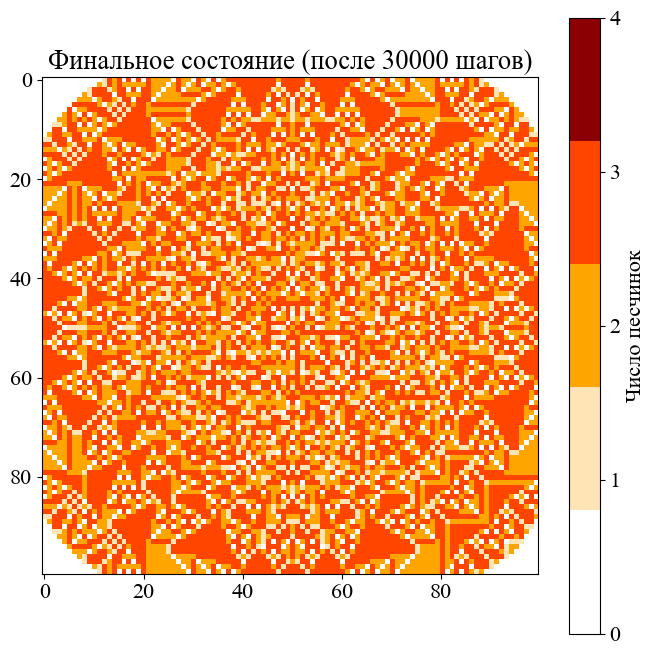

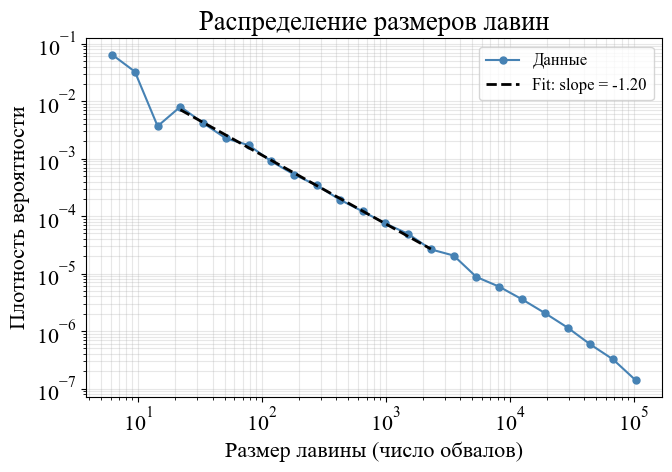

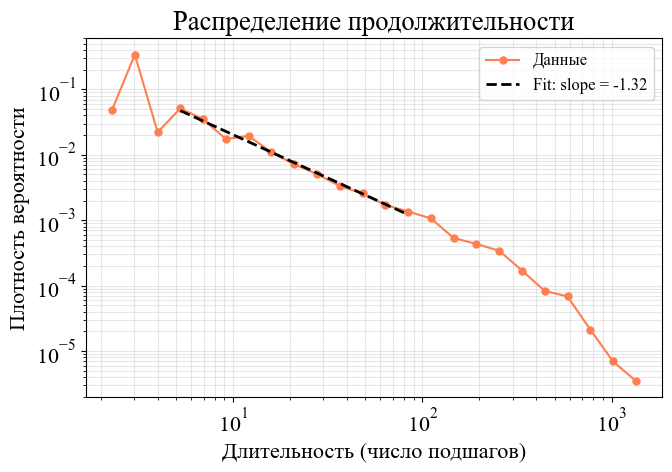

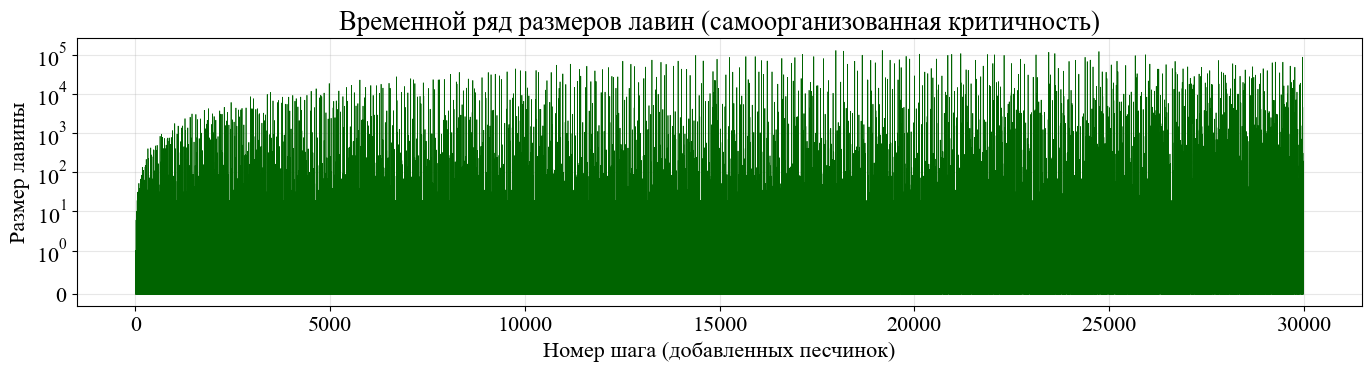


Анимация сохранена в sandpile_animation.gif


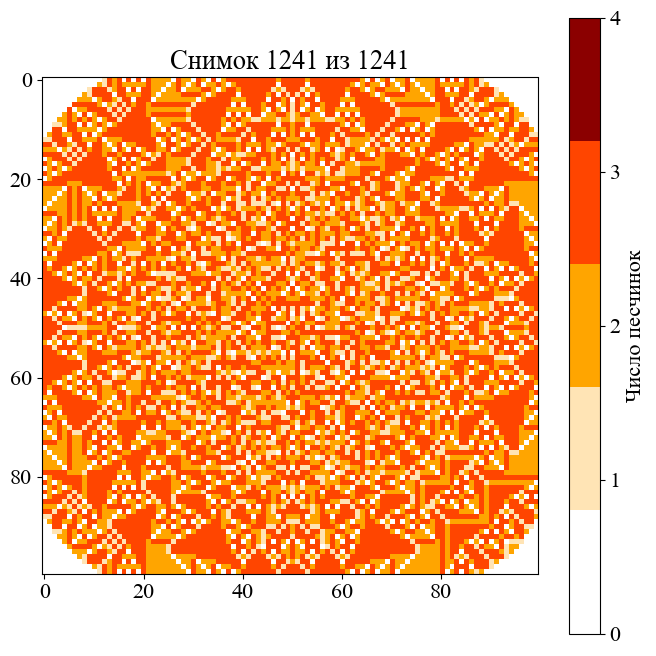

In [4]:
# ============================================================
#  МОДЕЛЬ ПЕСЧАНОЙ КУЧИ (BTW)
# ============================================================
class SandpileCA:
    """
    Клеточный автомат песчаной кучи Бака–Танга–Визенфельда.

    Правила:
      * В центральную клетку добавляется одна песчинка за такт.
      * Если в клетке >= h песчинок, она обваливается:
          - теряет h песчинок,
          - каждый из 4 соседей (фон Неймана) получает +1,
          - песчинки, ушедшие за границу, исчезают (сток).
      * Обвалы происходят синхронно, пока все клетки не станут устойчивыми.

    Дополнительно поддерживается режим периодических границ
    (boundary='periodic'), который убирает потери песчинок в сток.
    """

    def __init__(self, size: int = 100, threshold: int = 4,
                 boundary: str = 'open'):
        assert boundary in ('open', 'periodic'), \
            "boundary must be 'open' or 'periodic'"
        self.size = size
        self.h = threshold
        self.boundary = boundary
        self.grid = np.zeros((size, size), dtype=np.int32)

    def add_grain(self, i: int = None, j: int = None):
        """Добавляет одну песчинку в выбранную клетку (по умолчанию — в центр)."""
        if i is None:
            i = self.size // 2
        if j is None:
            j = self.size // 2
        self.grid[i, j] += 1

    def _distribute(self, unstable):
        """
        Возвращает массив delta (приращений), который надо прибавить
        к grid после обвала всех неустойчивых клеток из маски unstable.

        Для 'open'     — соседи на границе отсутствуют, песчинки теряются.
        Для 'periodic' — соседи «заворачиваются» через np.roll.
        """
        delta = np.zeros_like(self.grid)
        if self.boundary == 'open':
            delta[:-1, :] += unstable[1:, :]   # верхний сосед
            delta[1:, :] += unstable[:-1, :]   # нижний сосед
            delta[:, :-1] += unstable[:, 1:]   # левый сосед
            delta[:, 1:] += unstable[:, :-1]   # правый сосед
        else:  # periodic
            delta += np.roll(unstable, 1, axis=0)
            delta += np.roll(unstable, -1, axis=0)
            delta += np.roll(unstable, 1, axis=1)
            delta += np.roll(unstable, -1, axis=1)
        return delta

    def relax(self):
        """
        Обрабатывает лавину: пока есть неустойчивые клетки,
        синхронно обваливает их.

        Возвращает:
            total_topplings : int  — число обвалов (размер лавины)
            area            : int  — число клеток, обвалившихся хотя бы раз
            duration        : int  — число подшагов релаксации
            lost            : int  — число песчинок, ушедших за границу
                                     (только для boundary='open')
        """
        total_topplings = 0
        affected_cells = set()
        lost_grains = 0
        duration = 0

        while True:
            unstable = self.grid >= self.h
            if not unstable.any():
                break

            duration += 1
            unstable_idx = np.argwhere(unstable)
            total_topplings += len(unstable_idx)

            for i, j in unstable_idx:
                affected_cells.add((i, j))

            # --- Синхронный обвал ---
            delta = self._distribute(unstable)
            self.grid[unstable] -= self.h

            # Потери = сколько должны были отдать - сколько реально отдали
            if self.boundary == 'open':
                lost_grains += int(unstable.sum()) * self.h - int(delta.sum())

            self.grid += delta

        return total_topplings, len(affected_cells), duration, lost_grains

    def step(self, i: int = None, j: int = None):
        """Один такт: добавить песчинку + релаксация."""
        self.add_grain(i, j)
        return self.relax()


# ============================================================
#  СТАТИСТИКА
# ============================================================
class Statistics:
    """Накопление статистики по лавинам и снимкам поля."""

    def __init__(self):
        self.t = []                    # номер шага
        self.avalanche_sizes = []      # размер (число обвалов)
        self.avalanche_areas = []      # площадь (число затронутых клеток)
        self.avalanche_durations = []  # длительность (число подшагов)
        self.avalanche_lost = []       # потеряно песчинок за границей
        self.grid_states = []          # снимки поля (для анимации)
        self.total_topplings = 0

    def append(self, t, size, area, duration, lost):
        self.t.append(t)
        self.avalanche_sizes.append(size)
        self.avalanche_areas.append(area)
        self.avalanche_durations.append(duration)
        self.avalanche_lost.append(lost)
        self.total_topplings += size


# ============================================================
#  ЗАПУСК СИМУЛЯЦИИ
# ============================================================
def run_simulation(size=100, n_steps=10000, threshold=4,
                   boundary='open',
                   record_every=500, record_min_size=200):
    """
    Запускает модель.

    Параметры:
        boundary        : 'open' или 'periodic'
        record_every    : сохранять снимок каждые N шагов
        record_min_size : дополнительно сохранять снимок при лавине >= порога
    """
    ca = SandpileCA(size=size, threshold=threshold, boundary=boundary)
    st = Statistics()
    st.grid_states.append(np.copy(ca.grid))

    for t in range(1, n_steps + 1):
        size_av, area_av, dur_av, lost_av = ca.step()
        st.append(t, size_av, area_av, dur_av, lost_av)

        # Сохраняем снимок выборочно
        if t % record_every == 0 or size_av >= record_min_size:
            st.grid_states.append(np.copy(ca.grid))

        if t % record_every == 0:
            print(f"Шаг {t:>6}: лавина={size_av:>6}, "
                  f"площадь={area_av:>6}, длит.={dur_av:>3}, "
                  f"всего обвалов={st.total_topplings}")

    return ca, st


# ============================================================
#  ВИЗУАЛИЗАЦИЯ
# ============================================================
def make_cmap(h):
    """Цветовая карта для h+1 значений."""
    base = ['#FFFFFF', '#FFE4B5', '#FFA500', '#FF4500', '#8B0000',
            '#4B0000', '#1A0000']
    colors = (base * ((h + 1) // len(base) + 1))[:h + 1]
    return ListedColormap(colors)


def plot_sandpile(ca: SandpileCA, ax=None, title="Песчаная куча"):
    """Визуализация текущего состояния поля."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    cmap = make_cmap(ca.h)
    im = ax.imshow(ca.grid, cmap=cmap, vmin=0, vmax=ca.h,
               interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax, ticks=range(ca.h + 1),
                        label="Число песчинок")
    ax.set_title(title)
   
    return ax


def _loglog_hist(ax, data, xlabel, title, color,
                 min_val=1, n_bins=25, fit_range=None):
    """
    Рисует нормированное лог-лог распределение с фильтром min_val
    и (опционально) линейной аппроксимацией наклона.

    fit_range : tuple (lo, hi) — диапазон центров бинов для фита.
                Если None, фит не строится.
    """
    data = data[data >= min_val]
    if len(data) < 2:
        ax.set_title(title + " (нет данных)")
        return None

    bins = np.logspace(np.log10(min_val), np.log10(data.max() + 1), n_bins)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])

    # Оставляем только непустые бины
    nonzero = hist > 0
    centers_nz = centers[nonzero]
    hist_nz = hist[nonzero]

    ax.loglog(centers_nz, hist_nz, 'o-', color=color,
              markersize=5, label='Данные')

    tau = None
    if fit_range is not None:
        lo, hi = fit_range
        mask_fit = (centers_nz >= lo) & (centers_nz <= hi)
        if mask_fit.sum() >= 3:
            coef = np.polyfit(np.log10(centers_nz[mask_fit]),
                              np.log10(hist_nz[mask_fit]), 1)
            tau = -coef[0]
            fit_y = 10 ** (coef[1]) * centers_nz[mask_fit] ** (-tau)
            ax.loglog(centers_nz[mask_fit], fit_y, '--',
                      color='black', linewidth=2,
                      label=f'Fit: slope = -{tau:.2f}')

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Плотность вероятности")
    ax.set_title(title)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=12)
    return tau


def plot_avalanche_distribution(st: Statistics,
                                min_size=5, min_area=5, min_dur=2):
    """
    Строит ТРИ ОТДЕЛЬНЫХ графика:
    распределение размеров, площадей и длительностей лавин.
    """
    sizes = np.array(st.avalanche_sizes)
    areas = np.array(st.avalanche_areas)
    durs  = np.array(st.avalanche_durations)

    if len(sizes) == 0:
        print("Нет данных о лавинах.")
        return

    # --- График 1: размеры ---
    fig1, ax1 = plt.subplots(figsize=(7, 5))
    tau_s = _loglog_hist(
        ax1, sizes,
        "Размер лавины (число обвалов)",
        "Распределение размеров лавин",
        'steelblue',
        min_val=min_size,
        fit_range=(20, 3000),
    )
    plt.tight_layout()

    # --- График 2: длительности ---
    fig3, ax3 = plt.subplots(figsize=(7, 5))
    tau_d = _loglog_hist(
        ax3, durs,
        "Длительность (число подшагов)",
        "Распределение продолжительности",
        'coral',
        min_val=min_dur,
        fit_range=(5, 100),
    )
    plt.tight_layout()

    # --- Вывод показателей ---
    print(f"\nОценка показателей степенного закона:")
    if tau_s is not None:
        print(f"  τ_s (размер)      = {tau_s:.3f}")
    if tau_d is not None:
        print(f"  τ_d (длительность)= {tau_d:.3f}")
    print("  Теория для 2D BTW: τ_s ≈ 1.0–1.3")

    return fig1, fig3



def plot_avalanche_time_series(st: Statistics):
    """Временной ряд размеров лавин (symlog по Y)."""
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(st.t, st.avalanche_sizes, linewidth=0.5, color='darkgreen')
    ax.set_xlabel("Номер шага (добавленных песчинок)")
    ax.set_ylabel("Размер лавины")
    ax.set_title("Временной ряд размеров лавин "
                 "(самоорганизованная критичность)")
    ax.set_yscale('symlog', linthresh=1)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def create_animation(ca, st, interval=100):
    """Анимация эволюции поля по сохранённым снимкам."""
    if len(st.grid_states) < 2:
        print("Недостаточно снимков для анимации.")
        return None, None

    fig, ax = plt.subplots(figsize=(8, 8))
    cmap = make_cmap(ca.h)
    im = ax.imshow(ca.grid, cmap=cmap, vmin=0, vmax=ca.h,
               interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax, ticks=range(ca.h + 1),
                        label="Число песчинок")
    title = ax.set_title("Песчаная куча: снимок 0")
    

    def update(frame):
        im.set_data(st.grid_states[frame])
        title.set_text(f"Снимок {frame} из {len(st.grid_states) - 1}")
        return im, title

    anim = FuncAnimation(fig, update, frames=len(st.grid_states),
                         interval=interval, blit=False)
    return anim, fig


# ============================================================
#  ЗАПУСК
# ============================================================
if __name__ == "__main__":
    print("=== МОДЕЛЬ ПЕСЧАНОЙ КУЧИ (BTW) ===\n")

    SIZE = 100
    STEPS = 30000          # больше шагов = чище хвост распределения
    THRESHOLD = 4
    BOUNDARY = 'open'      # 'open' или 'periodic'

    print(f"Поле: {SIZE}×{SIZE}, порог h={THRESHOLD}, "
          f"шагов: {STEPS}, границы: {BOUNDARY}\n")

    ca, st = run_simulation(
        size=SIZE,
        n_steps=STEPS,
        threshold=THRESHOLD,
        boundary=BOUNDARY,
        record_every=1000,
        record_min_size=500,
    )

    sizes = np.array(st.avalanche_sizes)
    nonempty = sizes[sizes > 0]

    print(f"\n=== ИТОГИ ===")
    print(f"Всего обвалов            : {st.total_topplings}")
    print(f"Число непустых лавин     : {len(nonempty)}")
    print(f"Средний размер лавины    : {nonempty.mean():.2f}")
    print(f"Медианный размер         : {np.median(nonempty):.0f}")
    print(f"Максимальная лавина      : {nonempty.max()}")
    if BOUNDARY == 'open':
        print(f"Потеряно песчинок в сток : {sum(st.avalanche_lost)}")

    # --- Графики ---
    plot_sandpile(ca, title=f"Финальное состояние (после {STEPS} шагов)")
    plot_avalanche_distribution(st, min_size=5, min_area=5, min_dur=2)
    plot_avalanche_time_series(st)
    plt.show()

    # --- Анимация ---
    anim, fig_anim = create_animation(ca, st, interval=150)
    if anim is not None:
        anim.save('sandpile_animation.gif', writer='pillow', fps=8)
        print("\nАнимация сохранена в sandpile_animation.gif")
    plt.show()

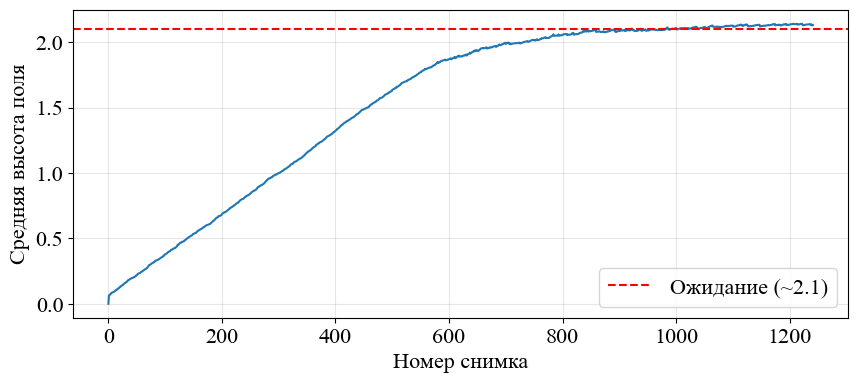

Средняя высота в конце: 2.132
Средняя высота в начале: 0.000


In [5]:
# --- Диагностика: выход на стационар ---
import numpy as np
import matplotlib.pyplot as plt

# Восстанавливаем эволюцию средней высоты по снимкам
avg_heights = [np.mean(g) for g in st.grid_states]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(avg_heights)), avg_heights, linewidth=1.5)
ax.set_xlabel("Номер снимка")
ax.set_ylabel("Средняя высота поля")
#ax.set_title("Выход системы на стационар")
ax.axhline(y=2.1, color='r', linestyle='--', label='Ожидание (~2.1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Средняя высота в конце: {avg_heights[-1]:.3f}")
print(f"Средняя высота в начале: {avg_heights[0]:.3f}")

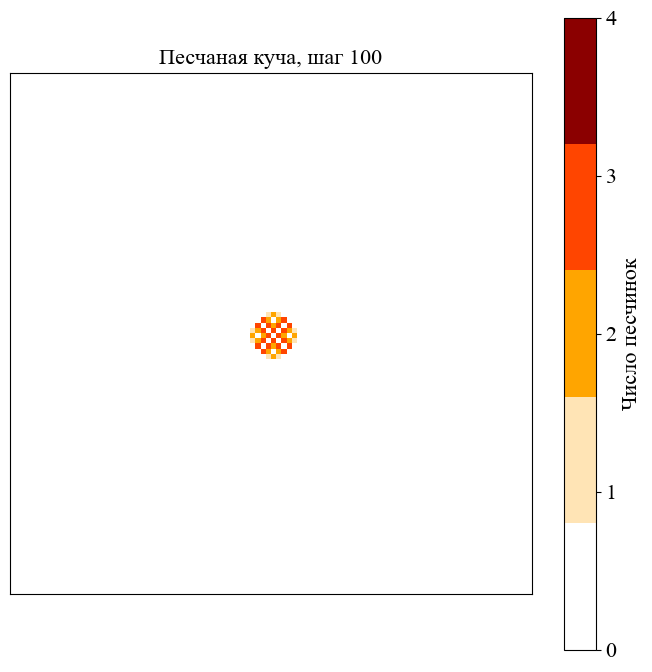

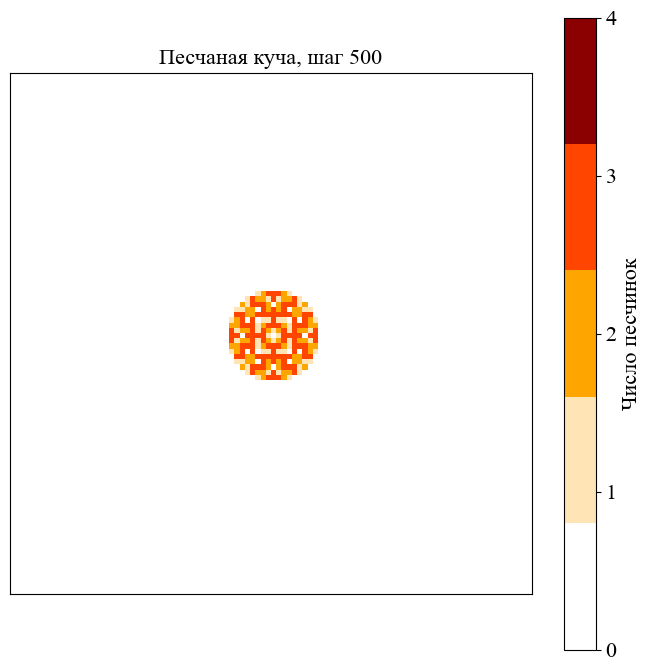

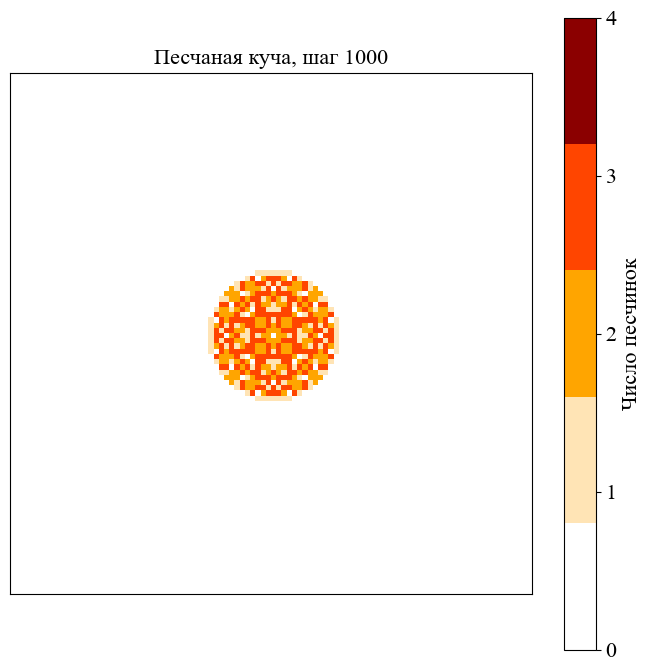

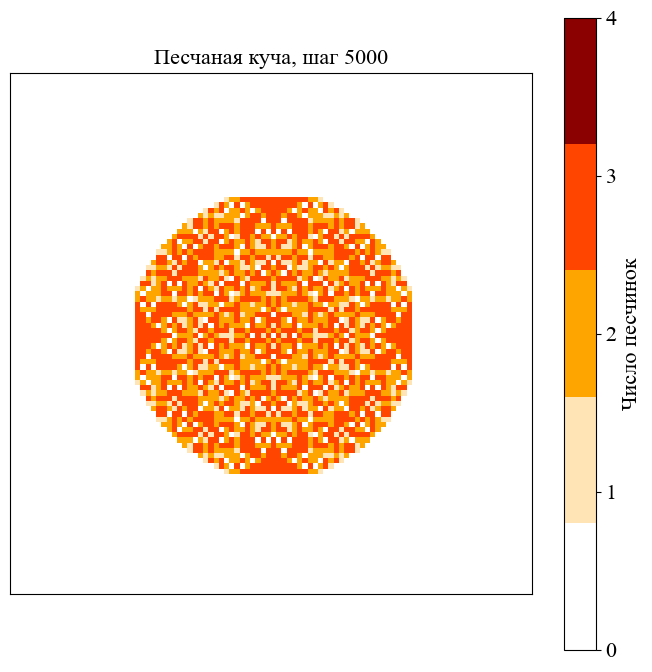

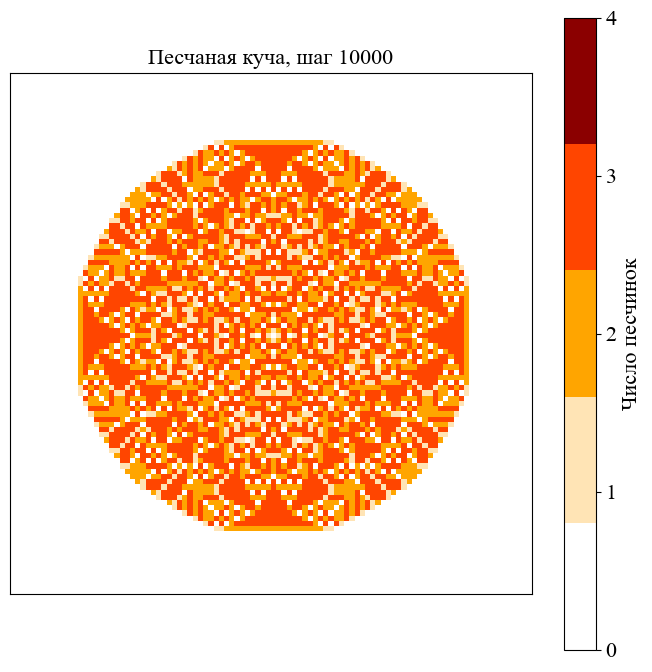

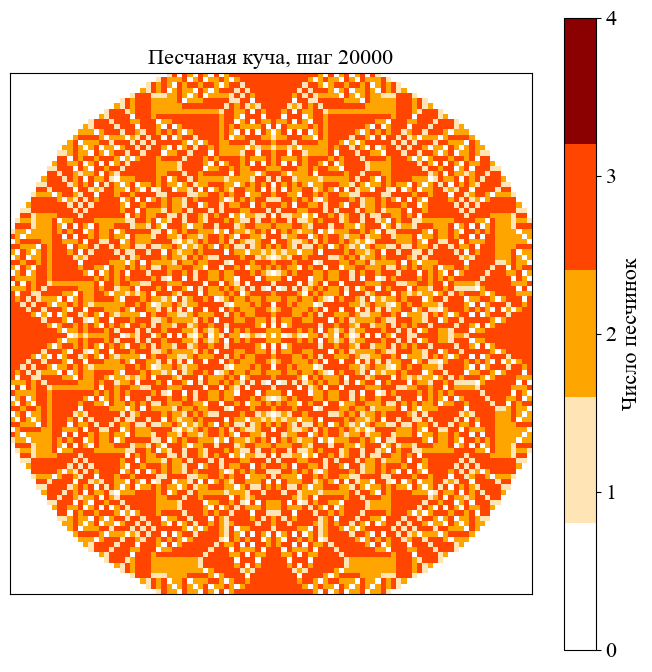

In [8]:
# ============================================================
#  ОТДЕЛЬНЫЕ РИСУНКИ: состояния на шагах 100, 500, 1000, 5000, 10000, 20000
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

SIZE = 100
THRESHOLD = 4
BOUNDARY = 'open'
SNAPSHOT_STEPS = {100, 500, 1000, 5000, 10000, 20000}

# --- Один прогон, сохраняем снимки точно в нужные шаги ---
ca_snap = SandpileCA(size=SIZE, threshold=THRESHOLD, boundary=BOUNDARY)
snapshots = {}

for t in range(1, max(SNAPSHOT_STEPS) + 1):
    ca_snap.step()
    if t in SNAPSHOT_STEPS:
        snapshots[t] = np.copy(ca_snap.grid)

# --- Рисуем каждый шаг на отдельном рисунке ---
cmap = make_cmap(THRESHOLD)

for step in sorted(snapshots):
    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.imshow(snapshots[step], cmap=cmap,
                   vmin=0, vmax=THRESHOLD,
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, ticks=range(THRESHOLD + 1),
                 label="Число песчинок")
    ax.set_title(f"Песчаная куча, шаг {step}", fontsize=16)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()
    # fig.savefig(f"sandpile_step_{step}.png", dpi=200, bbox_inches='tight')